In [ ]:
import math
from pathlib import Path

import cv2
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Polygon as MplPolygon


# ──────────────────────────────────────────────────────────────────────────────
# 1.  GABOR FILTER BANK
# ──────────────────────────────────────────────────────────────────────────────

def build_gabor_bank(ksize: int = 9, sigma: float = 3.0, lambdas: tuple = (6, 10, 16), n_orientations: int = 8,
    gamma: float = 0.8) -> list:

    kernels = []
    for lam in lambdas:
        for i in range(n_orientations):
            theta = i * math.pi / n_orientations          # evenly covers [0, π)
            k = cv2.getGaborKernel(
                (ksize, ksize), sigma, theta, lam, gamma,
                psi=0, ktype=cv2.CV_32F,
            )
            k_sum = k.sum()
            if abs(k_sum) > 1e-6:
                k /= k_sum            # DC-normalise: zero mean response
            kernels.append((theta, lam, k))
    return kernels


def apply_gabor_bank(gray_f32: np.ndarray, kernels: list) -> np.ndarray:
    h_energy = np.zeros_like(gray_f32)
    v_energy = np.zeros_like(gray_f32)

    for theta, _lam, k in kernels:
        resp = np.abs(cv2.filter2D(gray_f32, cv2.CV_32F, k))
        if abs(theta) < 0.25:                          # ≈ horizontal
            h_energy += resp
        elif abs(theta - math.pi / 2) < 0.25:         # ≈ vertical
            v_energy += resp

    return np.minimum(h_energy, v_energy)


# ──────────────────────────────────────────────────────────────────────────────
# 2.  PRE-PROCESSING
# ──────────────────────────────────────────────────────────────────────────────

def contrast_stretch(gray_u8: np.ndarray) -> np.ndarray:
    lo, hi = int(gray_u8.min()), int(gray_u8.max())
    if hi == lo:
        return gray_u8.copy()
    return np.clip(
        (gray_u8.astype(np.float32) - lo) / (hi - lo) * 255.0, 0, 255
    ).astype(np.uint8)


# ──────────────────────────────────────────────────────────────────────────────
# 3.  FINDER PATTERN DETECTOR  —  1 : 1 : 3 : 1 : 1 scan
# ──────────────────────────────────────────────────────────────────────────────

def find_finder_patterns(
    gray_u8: np.ndarray,
    cluster_dist: int = 25,
) -> tuple:

    h, w = gray_u8.shape
    _, bw = cv2.threshold(gray_u8, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    def _matches_ratio(runs: list) -> bool:
        """True iff the last 5 run-lengths satisfy 1:1:3:1:1."""
        if len(runs) < 5:
            return False
        seg   = runs[-5:]
        total = sum(seg)
        if total < 5:
            return False
        unit      = total / 7.0    # one module = total / (1+1+3+1+1)
        tolerance = 0.6            # allow ±60% per segment
        return all(abs(r - p * unit) <= tolerance * unit
                   for r, p in zip(seg, [1, 1, 3, 1, 1]))

    raw_hits = []
    for y in range(0, h, 2):         # skip alternate rows for speed
        row  = bw[y, :]
        runs, cur, cnt = [], int(row[0] > 0), 1
        for x in range(1, w):
            px = int(row[x] > 0)
            if px == cur:
                cnt += 1
            else:
                runs.append(cnt)
                cur, cnt = px, 1
        runs.append(cnt)

        for i in range(len(runs) - 4):
            if _matches_ratio(runs[i: i + 5]):
                cx = sum(runs[:i]) + sum(runs[i: i + 5]) // 2
                raw_hits.append((int(cx), int(y)))

    if not raw_hits:
        return [], None

    # Cluster: merge points within cluster_dist pixels into one centre
    pts  = np.array(raw_hits, dtype=np.float32)
    used = np.zeros(len(pts), dtype=bool)
    centres = []
    for i in range(len(pts)):
        if used[i]:
            continue
        nearby = np.linalg.norm(pts - pts[i], axis=1) < cluster_dist
        centres.append(tuple(pts[nearby].mean(axis=0).astype(int)))
        used[nearby] = True

    if len(centres) < 2:
        return centres, None

    xs   = [c[0] for c in centres]
    ys   = [c[1] for c in centres]
    span = max(max(xs) - min(xs), max(ys) - min(ys), 1)
    pad  = max(40, int(span * 0.35))      # generous padding so ROI covers the tag

    return centres, (
        max(0,     min(xs) - pad),
        max(0,     min(ys) - pad),
        min(w - 1, max(xs) + pad),
        min(h - 1, max(ys) + pad),
    )


# ──────────────────────────────────────────────────────────────────────────────
# 4.  CORNER ORDERING UTILITIES
# ──────────────────────────────────────────────────────────────────────────────

def _order_tl_tr_br_bl(pts: np.ndarray) -> np.ndarray:

    pts = pts.reshape(4, 2).astype(np.float32)
    s   = pts.sum(axis=1)
    d   = np.diff(pts, axis=1).ravel()
    return np.array([
        pts[np.argmin(s)],   # TL
        pts[np.argmin(d)],   # TR
        pts[np.argmax(s)],   # BR
        pts[np.argmax(d)],   # BL
    ], dtype=np.float32)


def _select_four_extreme(pts: np.ndarray) -> np.ndarray:

    return _order_tl_tr_br_bl(pts)


# ──────────────────────────────────────────────────────────────────────────────
# 5.  BLOB SCORING  (Path B only)
# ──────────────────────────────────────────────────────────────────────────────

def _score_blob(
    stats, label_id: int,
    gabor_norm: np.ndarray,
    finder_centres: list,
    labels: np.ndarray,
) -> float:
    """
    Rank a connected-component blob on three signals:

    squareness  (weight 0.25) — QR tags are nearly square; aspect² penalises
                                elongated blobs.
    gabor_mean  (weight 0.35) — mean Gabor energy inside the blob; high energy
                                means grid-like texture → likely a tag.
    finder_hit  (weight 0.40) — fraction of known finder centres that fall
                                inside this blob's bounding box. The highest
                                weight because finders are the most reliable cue.
    """
    x  = int(stats[label_id, cv2.CC_STAT_LEFT])
    y  = int(stats[label_id, cv2.CC_STAT_TOP])
    bw = int(stats[label_id, cv2.CC_STAT_WIDTH])
    bh = int(stats[label_id, cv2.CC_STAT_HEIGHT])

    squareness = (min(bw, bh) / max(bw, bh)) ** 2 if max(bw, bh) > 0 else 0
    gabor_mean = float(gabor_norm[labels == label_id].mean()) / 255.0
    n_hits     = sum(1 for (fx, fy) in finder_centres
                     if x <= fx <= x + bw and y <= fy <= y + bh)
    finder_hit = min(n_hits / 3.0, 1.0)    # cap at 1 (three finders = perfect)

    return 0.25 * squareness + 0.35 * gabor_mean + 0.40 * finder_hit


# ──────────────────────────────────────────────────────────────────────────────
# 6.  MASK CLEAN-UP  +  CORNER DETECTION ON A BINARY MASK CROP
# ──────────────────────────────────────────────────────────────────────────────

def _build_clean_mask(tag_mask_crop: np.ndarray) -> np.ndarray:

    h, w = tag_mask_crop.shape[:2]

    # Step 1 — inner 60% window
    margin_y = int(h * 0.20)
    margin_x = int(w * 0.20)
    cy1, cy2 = margin_y, h - margin_y
    cx1, cx2 = margin_x, w - margin_x

    centre_mask = np.zeros_like(tag_mask_crop)
    centre_mask[cy1:cy2, cx1:cx2] = tag_mask_crop[cy1:cy2, cx1:cx2]

    # Step 2 — connected components on centre window
    n, labels, stats, _ = cv2.connectedComponentsWithStats(centre_mask)
    if n < 2:
        # Nothing found in centre → fall back to largest blob in full mask
        n, labels, stats, _ = cv2.connectedComponentsWithStats(tag_mask_crop)
        if n < 2:
            return tag_mask_crop.copy()

    # Step 3 — largest blob in the centre window
    largest_label = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    bx = int(stats[largest_label, cv2.CC_STAT_LEFT])
    by = int(stats[largest_label, cv2.CC_STAT_TOP])
    bw = int(stats[largest_label, cv2.CC_STAT_WIDTH])
    bh = int(stats[largest_label, cv2.CC_STAT_HEIGHT])

    # Step 4 — re-extract from full mask with a small pad
    # (the blob may extend slightly beyond the centre window)
    pad = 10
    rx1, ry1 = max(0, bx - pad), max(0, by - pad)
    rx2, ry2 = min(w, bx + bw + pad), min(h, by + bh + pad)

    region = np.zeros_like(tag_mask_crop)
    region[ry1:ry2, rx1:rx2] = tag_mask_crop[ry1:ry2, rx1:rx2]

    n2, labels2, stats2, _ = cv2.connectedComponentsWithStats(region)
    if n2 < 2:
        # Padded region empty — return the centre-window blob as-is
        clean = np.zeros_like(tag_mask_crop)
        clean[labels == largest_label] = 255
        return clean

    largest2 = 1 + int(np.argmax(stats2[1:, cv2.CC_STAT_AREA]))
    clean = np.zeros_like(tag_mask_crop)
    clean[labels2 == largest2] = 255
    return clean


def detect_corners_on_mask(
    tag_mask_crop: np.ndarray,
    tag_gray_crop: np.ndarray,
) -> tuple:

    crop_h, crop_w = tag_mask_crop.shape[:2]

    # Step 0 — remove border noise; keep only the dominant central blob
    clean_mask = _build_clean_mask(tag_mask_crop)

    # Step 1 — contours on the cleaned mask
    contours, _ = cv2.findContours(
        clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, cv2.cvtColor(tag_mask_crop, cv2.COLOR_GRAY2BGR), clean_mask

    # Step 2 — convex hull of largest contour
    cnt  = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(cnt)

    # Step 3 — polygon approximation (ε = 5% of perimeter)
    eps    = 0.05 * cv2.arcLength(hull, closed=True)
    approx = cv2.approxPolyDP(hull, eps, closed=True)

    n_pts = len(approx)
    if n_pts < 4:
        corners_raw = np.array(
            [[0, 0], [crop_w, 0], [crop_w, crop_h], [0, crop_h]],
            dtype=np.float32,
        )
    elif n_pts == 4:
        corners_raw = approx.reshape(4, 2).astype(np.float32)
    else:
        corners_raw = _select_four_extreme(approx)

    # Step 4 — sub-pixel refinement
    corners_sp = cv2.cornerSubPix(
        tag_gray_crop,
        corners_raw.reshape(-1, 1, 2),
        winSize=(5, 5),
        zeroZone=(-1, -1),
        criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001),
    ).reshape(4, 2)

    # Step 5 — canonical ordering TL / TR / BR / BL
    corners = _order_tl_tr_br_bl(corners_sp)

    # Visualisation — draw on the clean mask so the interviewer sees what
    # the corner detector actually operated on, not the raw noisy input
    vis = cv2.cvtColor(clean_mask, cv2.COLOR_GRAY2BGR)
    cv2.polylines(vis, [corners.astype(np.int32)],
                  isClosed=True, color=(0, 255, 0), thickness=2)
    for i, (cx, cy) in enumerate(corners):
        cv2.circle(vis, (int(cx), int(cy)), 5, (0, 0, 255), -1)
        cv2.putText(vis, ["TL", "TR", "BR", "BL"][i],
                    (int(cx) + 4, int(cy) - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1)
    cv2.rectangle(vis, (0, 0), (crop_w - 1, crop_h - 1), (255, 165, 0), 1)

    return corners, vis, clean_mask


# ──────────────────────────────────────────────────────────────────────────────
# 7.  SHARED GABOR → MORPH PIPELINE
# ──────────────────────────────────────────────────────────────────────────────

def _gabor_morph(
    gray_u8: np.ndarray,
    kernels: list,
    smooth_iters: int,
    threshold: int,
    erode_iters: int,
    dilate_iters: int,
) -> tuple:
    """
    Gabor energy → iterative Gaussian blur → normalise → threshold → morph.

    Why iterative blur?
    Multiple Gaussian passes progressively merge adjacent high-energy pixels
    into solid blobs while suppressing high-frequency noise.

    Why erode then dilate?
    Erosion removes thin noise filaments; dilation re-fills the tag body.

    Returns
    -------
    norm_u8 : normalised Gabor score map (uint8)
    binary  : thresholded binary (uint8)
    morph   : cleaned binary for connected-component analysis (uint8)
    """
    score = apply_gabor_bank(gray_u8.astype(np.float32), kernels)

    blurred = score.copy()
    for _ in range(smooth_iters):
        blurred = cv2.GaussianBlur(blurred, (5, 5), 0)

    norm = np.zeros_like(blurred)
    cv2.normalize(blurred, norm, 0, 255, cv2.NORM_MINMAX)
    norm_u8 = norm.astype(np.uint8)

    _, binary = cv2.threshold(norm_u8, threshold, 255, cv2.THRESH_BINARY)

    se    = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    morph = cv2.erode(binary, se, iterations=erode_iters)
    morph = cv2.dilate(morph, se, iterations=dilate_iters)

    return norm_u8, binary, morph


# ──────────────────────────────────────────────────────────────────────────────
# 8.  MAIN DETECTOR CLASS
# ──────────────────────────────────────────────────────────────────────────────

class ClassicalQRDetector:
    """
    Finder-guided QR / fiducial tag corner detector.

    PATH A  Finder-guided
    ─────────────────────
    Requires ≥ 2 finder centres (from the 1:1:3:1:1 scan).
    Crops an ROI around those centres, runs Gabor + morph only inside
    the ROI, extracts the largest connected-component blob, then calls
    detect_corners_on_mask on that tight crop.
    Faster and more precise because the noisy background is excluded.

    Rejection
    ─────────
    Returns None if < 2 finder centres are found.
    """

    def __init__(
        self,
        gabor_lambdas: tuple     = (6, 10, 16),
        gabor_ksize: int         = 9,
        gabor_sigma: float       = 3.0,
        gabor_orientations: int  = 8,
        smooth_iters: int        = 3,
        threshold: int           = 30,
        erode_iters: int         = 1,
        dilate_iters: int        = 4,
        min_blob_area: int       = 500,
        confidence_ratio: float  = 1.5,
        finder_cluster_dist: int = 25,
    ):
        self._kernels             = build_gabor_bank(
            gabor_ksize, gabor_sigma, gabor_lambdas, gabor_orientations)
        self._smooth_iters        = smooth_iters
        self._threshold           = threshold
        self._erode_iters         = erode_iters
        self._dilate_iters        = dilate_iters
        self._min_blob_area       = min_blob_area
        self._confidence_ratio    = confidence_ratio
        self._finder_cluster_dist = finder_cluster_dist

    # ── private helpers ────────────────────────────────────────────────────

    @staticmethod
    def _to_gray(img_bgr: np.ndarray) -> np.ndarray:
        return contrast_stretch(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY))

    def _run_morph(self, gray_u8: np.ndarray) -> tuple:
        return _gabor_morph(
            gray_u8, self._kernels,
            self._smooth_iters, self._threshold,
            self._erode_iters, self._dilate_iters,
        )

    def _largest_blob(self, morph: np.ndarray) -> tuple:
        """Return (mask, bbox) for the single largest valid blob, or (None, None)."""
        n, labels, stats, _ = cv2.connectedComponentsWithStats(morph)
        best_mask, best_area, best_bbox = None, 0, None
        for lid in range(1, n):
            area = int(stats[lid, cv2.CC_STAT_AREA])
            if area >= self._min_blob_area and area > best_area:
                best_area = area
                best_mask = (labels == lid).astype(np.uint8) * 255
                bx = int(stats[lid, cv2.CC_STAT_LEFT])
                by = int(stats[lid, cv2.CC_STAT_TOP])
                bw = int(stats[lid, cv2.CC_STAT_WIDTH])
                bh = int(stats[lid, cv2.CC_STAT_HEIGHT])
                best_bbox = (bx, by, bx + bw, by + bh)
        return best_mask, best_bbox

    def _best_scored_blob(
        self, morph: np.ndarray,
        norm_u8: np.ndarray,
        finder_centres: list,
    ) -> tuple:
        """Score all valid blobs; return (mask, bbox, confidence)."""
        n, labels, stats, _ = cv2.connectedComponentsWithStats(morph)
        valid = np.where(stats[1:, cv2.CC_STAT_AREA] >= self._min_blob_area)[0]
        if len(valid) == 0:
            return None, None, 0.0

        scored = sorted(
            [(_score_blob(stats, int(i) + 1, norm_u8, finder_centres, labels),
              int(i) + 1)
             for i in valid],
            reverse=True,
        )
        best_score, best_label = scored[0]

        # Confidence = how much better the best blob is than the runner-up.
        # A ratio ≥ confidence_ratio means the detector is sure which blob is the tag.
        confidence = (best_score / scored[1][0]
                      if len(scored) >= 2 and scored[1][0] > 0
                      else 99.0)

        bx  = int(stats[best_label, cv2.CC_STAT_LEFT])
        by  = int(stats[best_label, cv2.CC_STAT_TOP])
        bw_ = int(stats[best_label, cv2.CC_STAT_WIDTH])
        bh_ = int(stats[best_label, cv2.CC_STAT_HEIGHT])
        return (
            (labels == best_label).astype(np.uint8) * 255,
            (bx, by, bx + bw_, by + bh_),
            confidence,
        )

    # ── public interface ───────────────────────────────────────────────────

    def detect(self, img_bgr: np.ndarray) -> tuple:
        """
        Detect a QR / fiducial tag and return its four corners.

        Parameters
        ----------
        img_bgr : uint8 BGR image

        Returns
        -------
        corners    : (4, 2) float32 [TL, TR, BR, BL] in full-image pixels
                     or None if no tag found
        bbox       : (x1, y1, x2, y2) or None
        confidence : float  (finder count for Path A; score ratio for Path B)
        debug      : dict of intermediate images for visualisation
        """
        full_gray = self._to_gray(img_bgr)
        norm_full, binary_full, morph_full = self._run_morph(full_gray)

        finder_centres, finder_bbox = find_finder_patterns(
            full_gray, cluster_dist=self._finder_cluster_dist)

        debug = dict(
            gray          = full_gray,
            qr_score      = norm_full,
            binary        = binary_full,
            morph         = morph_full,
            finder_pts    = finder_centres,
            tag_mask_crop = None,
            clean_mask    = None,       # dominant-blob mask from _build_clean_mask
            tag_crop      = None,
            tag_crop_vis  = None,
            path          = 'none',
        )

        # ── PATH A : Finder-guided ─────────────────────────────────────────
        if finder_bbox is not None and len(finder_centres) >= 2:
            x1, y1, x2, y2 = finder_bbox
            roi_gray = full_gray[y1:y2, x1:x2]
            roi_bgr  = img_bgr[y1:y2, x1:x2]

            if roi_gray.size > 0:
                norm_roi, binary_roi, morph_roi = self._run_morph(roi_gray)

                blob_mask, blob_bbox = self._largest_blob(morph_roi)
                if blob_mask is None:                  # nothing found → use full ROI
                    blob_mask = morph_roi
                    blob_bbox = (0, 0, morph_roi.shape[1], morph_roi.shape[0])

                bx1, by1, bx2, by2 = blob_bbox
                tag_mask_crop = blob_mask[by1:by2, bx1:bx2]
                tag_gray_crop = roi_gray[by1:by2, bx1:bx2]
                tag_color_crop = roi_bgr[by1:by2, bx1:bx2]

                corners_crop, vis, clean_mask = detect_corners_on_mask(tag_mask_crop, tag_gray_crop)

                if corners_crop is not None:
                    ox, oy = x1 + bx1, y1 + by1
                    corners_full = corners_crop + np.array([ox, oy], dtype=np.float32)

                    ch, cw = tag_mask_crop.shape[:2]
                    debug.update(
                        qr_score      = norm_roi,
                        binary        = binary_roi,
                        morph         = morph_roi,
                        tag_mask_crop = tag_mask_crop,
                        clean_mask    = clean_mask,
                        tag_crop      = tag_color_crop,
                        tag_crop_vis  = vis,
                        path          = 'A-finder-guided',
                    )
                    return (corners_full,
                            (ox, oy, ox + cw, oy + ch),
                            float(len(finder_centres)),
                            debug)

        # ── PATH B : Blob fallback ─────────────────────────────────────────
        debug['path'] = 'B-blob-fallback'

        blob_mask, blob_bbox, confidence = self._best_scored_blob(
            morph_full, norm_full, finder_centres)

        if blob_mask is None or confidence < self._confidence_ratio:
            return None, None, confidence, debug

        bx1, by1, bx2, by2 = blob_bbox
        tag_mask_crop  = blob_mask[by1:by2, bx1:bx2]
        tag_gray_crop  = full_gray[by1:by2, bx1:bx2]
        tag_color_crop = img_bgr[by1:by2, bx1:bx2]

        corners_crop, vis, clean_mask = detect_corners_on_mask(tag_mask_crop, tag_gray_crop)
        if corners_crop is None:
            return None, blob_bbox, confidence, debug

        corners_full = corners_crop + np.array([bx1, by1], dtype=np.float32)
        ch, cw = tag_mask_crop.shape[:2]
        debug.update(
            tag_mask_crop = tag_mask_crop,
            clean_mask    = clean_mask,
            tag_crop      = tag_color_crop,
            tag_crop_vis  = vis,
        )
        return (corners_full,
                (bx1, by1, bx1 + cw, by1 + ch),
                confidence,
                debug)


# ──────────────────────────────────────────────────────────────────────────────
# 9.  VISUALISATION
# ──────────────────────────────────────────────────────────────────────────────

def visualise(img_bgr, corners, bbox, conf, debug, title=""):
    """
    Two-row debug display.

    Row 1 : Original (with overlays) + Greyscale + Gabor Score + Binary + Morph
    Row 2 : tag_mask_crop  |  colour crop  |  corners on crop
    """
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    has_crop = debug.get("tag_mask_crop") is not None

    # ── Row 1 ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(24, 4))
    for ax, (lbl, im, cm) in zip(axes, [
        ("Original",    img_rgb,           None),
        ("Greyscale",   debug["gray"],      "gray"),
        ("Gabor Score", debug["qr_score"],  "hot"),
        ("Binary",      debug["binary"],    "gray"),
        ("Morph",       debug["morph"],     "gray"),
    ]):
        ax.imshow(im, cmap=cm)
        ax.set_title(lbl, fontsize=9)
        ax.axis("off")

    ax0 = axes[0]
    for fx, fy in debug.get("finder_pts", []):
        ax0.plot(fx, fy, "c+", markersize=14, markeredgewidth=2)

    if corners is not None:
        ax0.add_patch(MplPolygon(corners, closed=True,
                                 lw=2, edgecolor="lime", facecolor="none"))
        for i, (cx, cy) in enumerate(corners):
            ax0.plot(cx, cy, "go", ms=7)
            ax0.text(cx + 4, cy - 5,
                     f"{['TL','TR','BR','BL'][i]}({int(cx)},{int(cy)})",
                     color="cyan", fontsize=7,
                     bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.5))

    if bbox is not None:
        bx1, by1, bx2, by2 = bbox
        ax0.add_patch(plt.Rectangle((bx1, by1), bx2 - bx1, by2 - by1,
                                    lw=1.5, edgecolor="orange",
                                    facecolor="none", linestyle="--"))

    status = "DETECTED" if corners is not None else "MISSED"
    fig.suptitle(
        f"{title}  [{status}]  conf={conf:.2f}  path={debug.get('path','')}\n"
        "lime=corners  orange--=bbox  cyan+=finder",
        color="lime" if corners is not None else "red", fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    # ── Row 2 ──────────────────────────────────────────────────────────────
    if has_crop:
        fig2, axes2 = plt.subplots(1, 4, figsize=(20, 4))

        axes2[0].imshow(debug["tag_mask_crop"], cmap="gray")
        axes2[0].set_title("tag_mask_crop  (raw Gabor mask)", fontsize=9)
        axes2[0].axis("off")

        axes2[1].imshow(debug["clean_mask"], cmap="gray")
        axes2[1].set_title("clean_mask  (dominant central blob)", fontsize=9)
        axes2[1].axis("off")

        axes2[2].imshow(cv2.cvtColor(debug["tag_crop"], cv2.COLOR_BGR2RGB))
        axes2[2].set_title("tag_crop  (colour)", fontsize=9)
        axes2[2].axis("off")

        axes2[3].imshow(cv2.cvtColor(debug["tag_crop_vis"], cv2.COLOR_BGR2RGB))
        axes2[3].set_title("Corners on clean_mask", fontsize=9)
        axes2[3].axis("off")

        if corners is not None:
            fig2.suptitle(
                "raw mask → clean mask (border noise removed) → colour → corners\n"
                f"Full-image bbox: {bbox}",
                fontsize=9,
            )
        plt.tight_layout()
        plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# 10.  ENTRY POINT
# ──────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    detector = ClassicalQRDetector(
        gabor_lambdas       = (12, 23, 28),   # tune to match tag module pitch
        gabor_ksize         = 9,
        gabor_sigma         = 4.0,
        smooth_iters        = 4,
        threshold           = 60,
        erode_iters         = 1,
        dilate_iters        = 3,
        min_blob_area       = 2000,
        confidence_ratio    = 1.5,
        finder_cluster_dist = 25,
    )

    image_dir = Path("/content/drive/MyDrive/images")   # ← adjust as needed

    for img_path in sorted(image_dir.glob("*.png")):
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"[WARN] Cannot read: {img_path.name}")
            continue

        corners, bbox, conf, debug = detector.detect(img)

        print(f"\n{'=' * 60}")
        print(f"Image  : {img_path.name}")
        print(f"Path   : {debug['path']}")
        print(f"Finders: {len(debug['finder_pts'])}  {debug['finder_pts']}")
        print(f"Conf   : {conf:.3f}")

        if corners is not None:
            print("Corners (full-image coordinates):")
            for label, (cx, cy) in zip(["TL", "TR", "BR", "BL"], corners):
                print(f"  {label}  x={cx:.1f}  y={cy:.1f}")
            if bbox:
                bx1, by1, bx2, by2 = bbox
                print(f"BBox   : ({bx1},{by1}) → ({bx2},{by2})  "
                      f"size={bx2-bx1}×{by2-by1}")
        else:
            print("No tag detected.")

        visualise(img, corners, bbox, conf, debug, title=img_path.name)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import torch
import cv2
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
from PIL import Image


class CornerDataset(Dataset):
    def __init__(self, csv_path, img_dir, transforms=None):
        self.df = pd.read_csv(csv_path, sep=',')
        self.img_dir = img_dir
        self.transforms = transforms

        # Filter to only rows where the image file actually exists
        mask = self.df['filename'].apply(
            lambda f: os.path.isfile(os.path.join(img_dir, f))
        )
        dropped = (~mask).sum()
        self.df = self.df[mask].reset_index(drop=True)
        print(f"Dataset: {len(self.df)} images found, {dropped} missing and skipped.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])  # safer than f-string join
        img = Image.open(img_path).convert('RGB')
        w, h = img.size

        corner_str = row['corners']
        if pd.notna(corner_str) and row['check_corners'] == 1:
            corners = np.array(list(map(float, corner_str.split()))).reshape(4, 2)
            corners = corners / np.array([w, h])
            keypoints = corners.flatten().astype(np.float32)
            has_tag = 1
            x_min = corners[:, 0].min()
            y_min = corners[:, 1].min()
            box_w = corners[:, 0].max() - x_min
            box_h = corners[:, 1].max() - y_min
            boxes = torch.tensor([[x_min, y_min, box_w, box_h]], dtype=torch.float32)
        else:
            keypoints = np.zeros(8, dtype=np.float32)
            has_tag = 0
            boxes = torch.zeros((1, 4), dtype=torch.float32)

        target = {
            'boxes': boxes,
            'labels': torch.tensor([0]),
            'keypoints': torch.tensor(keypoints),
            'has_tag': torch.tensor(has_tag, dtype=torch.float32)
        }

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

In [ ]:
# this is cell 2nd in colab
import torch
import torch.nn as nn
from transformers import DetrForObjectDetection, DetrConfig
from transformers import DetrImageProcessor

class DetrForKeypoint(nn.Module):
    def __init__(self, num_keypoints=8):
        super().__init__()
        self.detr = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
        hidden_dim = self.detr.config.d_model   # ✓ FIX: config is on top-level model


        self.keypoint_head = nn.Linear(hidden_dim, num_keypoints)
        self.presence_head = nn.Linear(hidden_dim, 1)

        # ✓ FIX: correct attribute paths for HuggingFace DETR

        for param in self.detr.model.backbone.parameters():

            param.requires_grad = False

        for param in self.detr.model.encoder.parameters():

            param.requires_grad = False

        for param in self.detr.model.decoder.parameters():

            param.requires_grad = False


    def forward(self, pixel_values, pixel_mask=None):
        outputs = self.detr.model(pixel_values, pixel_mask=pixel_mask)
        hidden_states = outputs.last_hidden_state   # (batch, num_queries, hidden_dim)
        query_feat = hidden_states[:, 0, :]          # (batch, hidden_dim)

        keypoints = self.keypoint_head(query_feat)
        presence = self.presence_head(query_feat).squeeze(-1)

        return {'keypoints': keypoints, 'presence_logits': presence}

In [ ]:
# this is cell 3rd in colab
def loss_fn(pred, target):
    kp_pred = pred['keypoints']
    presence_pred = pred['presence_logits']
    kp_target = target['keypoints']
    has_tag = target['has_tag']

    # Presence loss (BCE)
    presence_loss = nn.BCEWithLogitsLoss()(presence_pred, has_tag)

    # Keypoint loss (smooth L1) only on positive samples
    mask = has_tag.bool()
    if mask.sum() > 0:
        kp_loss = nn.SmoothL1Loss()(kp_pred[mask], kp_target[mask])
    else:
        kp_loss = torch.tensor(0.0, device=kp_pred.device)

    total_loss = presence_loss + kp_loss
    return total_loss, presence_loss, kp_loss

✓ Device: cuda


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

Epoch 01/40  total=1.0897  presence=0.8722  keypoint=0.2175
Epoch 02/40  total=0.8564  presence=0.7024  keypoint=0.1540
Epoch 03/40  total=0.6631  presence=0.5592  keypoint=0.1039
Epoch 04/40  total=0.5247  presence=0.4554  keypoint=0.0693
Epoch 05/40  total=0.4570  presence=0.4049  keypoint=0.0521
Epoch 06/40  total=0.4003  presence=0.3587  keypoint=0.0416
Epoch 07/40  total=0.3569  presence=0.3230  keypoint=0.0339
Epoch 08/40  total=0.3202  presence=0.2899  keypoint=0.0303
Epoch 09/40  total=0.2943  presence=0.2684  keypoint=0.0259
Epoch 10/40  total=0.2658  presence=0.2424  keypoint=0.0234
Epoch 11/40  total=0.2555  presence=0.2315  keypoint=0.0240
Epoch 12/40  total=0.2200  presence=0.2001  keypoint=0.0198
Epoch 13/40  total=0.2175  presence=0.1961  keypoint=0.0214
Epoch 14/40  total=0.1968  presence=0.1777  keypoint=0.0191
Epoch 15/40  total=0.1844  presence=0.1656  keypoint=0.0188
Epoch 16/40  total=0.1743  presence=0.1557  keypoint=0.0186
Epoch 17/40  total=0.1657  presence=0.14

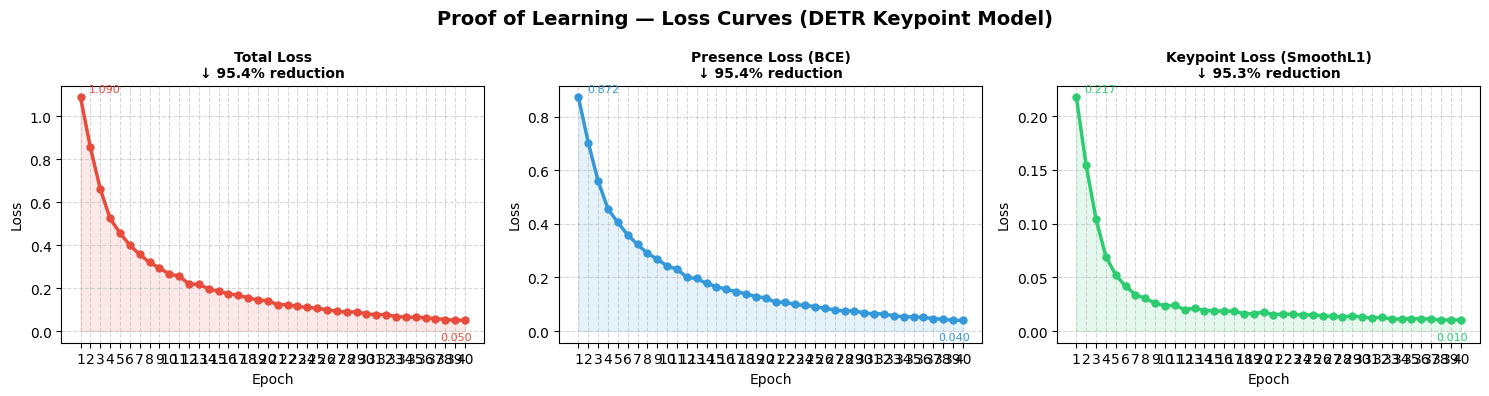


✓ Loss curve saved to /content/loss_curve.png
  Total loss:    1.0897 → 0.0502
  Presence loss: 0.8722 → 0.0400
  Keypoint loss: 0.2175 → 0.0102


In [ ]:
# Cell — Training + Save
import warnings
import os
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('PIL').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import DetrForObjectDetection, DetrImageProcessor
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Config ──────────────────────────────────────────────
SUBSET_SIZE = 200
BATCH_SIZE  = 4
EPOCHS      = 20
LR          = 1e-4
SAVE_PATH   = '/content/drive/MyDrive/detr_keypoint.pth'
# ────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

subset = torch.utils.data.Subset(dataset, range(min(SUBSET_SIZE, len(dataset))))
loader = torch.utils.data.DataLoader(
    subset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

model = DetrForKeypoint().to(device)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

# ── Training loop ────────────────────────────────────────
history = {'total': [], 'presence': [], 'keypoint': []}

for epoch in range(EPOCHS):
    model.train()
    ep_total, ep_pres, ep_kp, n = 0, 0, 0, 0

    for images, targets in loader:
        encoding     = processor(images=list(images), return_tensors="pt")
        pixel_values = encoding["pixel_values"].to(device)
        pixel_mask   = encoding["pixel_mask"].to(device)

        target_batch = {
            'keypoints': torch.stack([t['keypoints'] for t in targets]).to(device),
            'has_tag':   torch.stack([t['has_tag']   for t in targets]).to(device),
        }

        optimizer.zero_grad()
        pred = model(pixel_values, pixel_mask=pixel_mask)
        loss, p_loss, kp_loss = loss_fn(pred, target_batch)
        loss.backward()
        optimizer.step()

        ep_total += loss.item()
        ep_pres  += p_loss.item()
        ep_kp    += kp_loss.item()
        n        += 1

    history['total'].append(ep_total / n)
    history['presence'].append(ep_pres / n)
    history['keypoint'].append(ep_kp / n)
    print(f"Epoch {epoch+1:02d}/{EPOCHS}  "
          f"total={history['total'][-1]:.4f}  "
          f"presence={history['presence'][-1]:.4f}  "
          f"keypoint={history['keypoint'][-1]:.4f}")

# ── Save weights (after training) ───────────────────────
torch.save({
    'epoch':                 EPOCHS,
    'model_state_dict':      model.state_dict(),
    'optimizer_state_dict':  optimizer.state_dict(),
    'history':               history,
    'total_loss':            history['total'][-1],
}, SAVE_PATH)
print(f"\n✓ Weights saved to {SAVE_PATH}")

# ── Plot ─────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Proof of Learning — Loss Curves (DETR Keypoint Model)", fontsize=14, fontweight='bold')

configs = [
    ('total',    'Total Loss',           '#e74c3c'),
    ('presence', 'Presence Loss (BCE)',   '#3498db'),
    ('keypoint', 'Keypoint Loss (SmoothL1)', '#2ecc71'),
]

for ax, (key, title, color) in zip(axes, configs):
    vals = history[key]
    ax.plot(epochs_range, vals, color=color, linewidth=2.5, marker='o', markersize=5)
    ax.fill_between(epochs_range, vals, alpha=0.12, color=color)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(epochs_range)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.annotate(f"{vals[0]:.3f}", (1, vals[0]),
                textcoords="offset points", xytext=(6, 4), fontsize=8, color=color)
    ax.annotate(f"{vals[-1]:.3f}", (EPOCHS, vals[-1]),
                textcoords="offset points", xytext=(-18, -14), fontsize=8, color=color)
    drop_pct = (vals[0] - vals[-1]) / vals[0] * 100
    ax.set_title(f"{title}\n↓ {drop_pct:.1f}% reduction", fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('/content/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Loss curve saved to /content/loss_curve.png")
print(f"  Total loss:    {history['total'][0]:.4f} → {history['total'][-1]:.4f}")
print(f"  Presence loss: {history['presence'][0]:.4f} → {history['presence'][-1]:.4f}")
print(f"  Keypoint loss: {history['keypoint'][0]:.4f} → {history['keypoint'][-1]:.4f}")

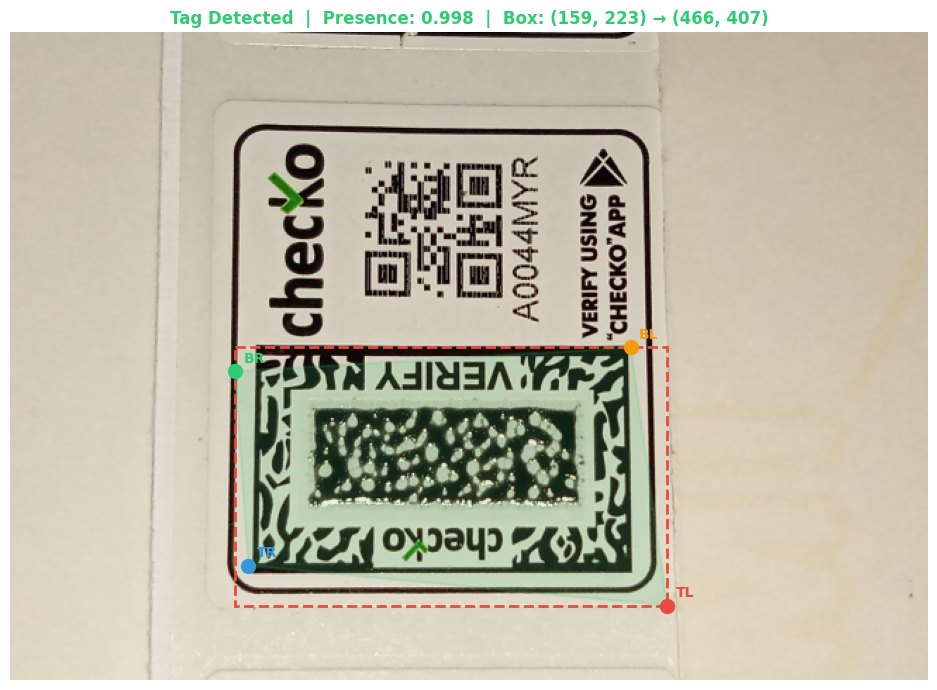

✓ Saved to /content/prediction.png

Predicted corners (absolute pixels):
  TL: (466.3, 406.6)
  TR: (168.7, 378.3)
  BR: (159.3, 240.3)
  BL: (440.4, 223.3)


In [ ]:
def predict(model, image_path, processor, threshold=0.5):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size

    encoding = processor(images=img, return_tensors="pt")

    model.eval()
    with torch.no_grad():
        pred = model(
            encoding['pixel_values'].to(device),
            pixel_mask=encoding['pixel_mask'].to(device)
        )
        presence_prob = torch.sigmoid(pred['presence_logits']).item()
        if presence_prob < threshold:
            print(f"No tag detected (presence prob: {presence_prob:.3f} < threshold {threshold})")
            return None, img, None
        keypoints_norm = pred['keypoints'].cpu().numpy().reshape(4, 2)
        keypoints_abs = keypoints_norm * np.array([w, h])
        return keypoints_abs.flatten(), img, presence_prob


def show_prediction(model, image_path, processor, threshold=0.5):
    result, img, presence_prob = predict(model, image_path, processor, threshold)

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(img)

    if result is None:
        ax.set_title("No tag detected", fontsize=14, color='red', fontweight='bold')
    else:
        corners = result.reshape(4, 2)  # [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]

        # Draw bounding box from min/max of corners
        x_min, y_min = corners[:, 0].min(), corners[:, 1].min()
        x_max, y_max = corners[:, 0].max(), corners[:, 1].max()
        box_w = x_max - x_min
        box_h = y_max - y_min

        rect = plt.Rectangle(
            (x_min, y_min), box_w, box_h,
            linewidth=2, edgecolor='#e74c3c', facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)

        # Draw the 4 predicted corners
        colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
        labels = ['TL', 'TR', 'BR', 'BL']
        for i, (corner, color, label) in enumerate(zip(corners, colors, labels)):
            ax.plot(*corner, 'o', color=color, markersize=10, zorder=5)
            ax.annotate(label, corner,
                        textcoords="offset points", xytext=(6, 6),
                        fontsize=10, fontweight='bold', color=color)

        # Draw polygon connecting corners
        polygon = plt.Polygon(corners, closed=True,
                              linewidth=2, edgecolor='#2ecc71',
                              facecolor='#2ecc71', alpha=0.15)
        ax.add_patch(polygon)

        ax.set_title(
            f"Tag Detected  |  Presence: {presence_prob:.3f}  |  "
            f"Box: ({x_min:.0f}, {y_min:.0f}) → ({x_max:.0f}, {y_max:.0f})",
            fontsize=12, fontweight='bold', color='#2ecc71'
        )

    ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/prediction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to /content/prediction.png")
    return result


# Usage
result = show_prediction(
    model,
    "/content/drive/MyDrive/images/A0044MYR_Flash0_A0044MYRfullhd_1632986364330_2.0.7.png",
    processor
)

if result is not None:
    corners = result.reshape(4, 2)
    print("\nPredicted corners (absolute pixels):")
    for i, (label, corner) in enumerate(zip(['TL', 'TR', 'BR', 'BL'], corners)):
        print(f"  {label}: ({corner[0]:.1f}, {corner[1]:.1f})")